# Mech Interp on DEQNs: Brock-Mirman Walkthrough

A six-chapter narrated example. We train tiny `LinearPlusMLP` networks on
Brock-Mirman at three risk-aversion settings, then peel them open chapter
by chapter.

Each chapter introduces one mech-interp move on a substrate where every
claim is checkable against a known economic solution.

**Outline:**
- Ch 0 — Setup: train the networks, see what they compute
- Ch 1 — Output decomposition (BK linearization vs MLP correction)
- Ch 2 — Per-neuron contributions inside the MLP correction
- Ch 3 — Linear probes: what do live neurons encode?
- Ch 4 — Ablation: causation vs correlation
- Ch 5 — The intensity dial: γ ∈ {1, 2, 5}
- Ch 6 — Honest limits and pointers forward

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from deqn_jax.config import NetworkConfig, OptimizerConfig, TrainConfig
from deqn_jax.interp import (
    ablate_neuron,
    branch_decompose,
    forward_with_activations,
    linear_probe,
    neuron_contributions,
)
from deqn_jax.training.trainer import train_from_config

FIGDIR = "../docs/dev/figures/interp"
GAMMAS = (1.0, 2.0, 5.0)
HIDDEN = (16, 16)
SEED = 0
EPISODES = 200

## Chapter 0 — Setup

We train three Brock-Mirman policies, one per γ. Each is a
`LinearPlusMLP` with hidden sizes `(16, 16)` and the same seed. The linear
branch is the Blanchard-Kahn first-order solution of the model (fixed,
not trained). The MLP branch is initialized so that the network *is* the
BK linearization at init; training carves the nonlinear correction.

Below we train all three networks, then plot the γ=2 learned policy on a
(k, z) grid. Chapters 1–4 focus on the γ=2 network; γ=1 and γ=5 come back
in Chapter 5.

In [2]:
def train_one(gamma: float):
    cfg = TrainConfig(
        model="brock_mirman",
        constants={"gamma": gamma},
        episodes=EPISODES,
        episode_length=128,
        batch_size=64,
        mc_samples=8,
        seed=SEED,
        network=NetworkConfig(
            type="linear_plus_mlp",
            hidden_sizes=HIDDEN,
            activation="tanh",
        ),
        optimizer=OptimizerConfig(name="adam", learning_rate=1e-3),
    )
    trained, history = train_from_config(cfg)
    final_loss = history["loss"][-1] if "loss" in history else float("nan")
    print(f"γ={gamma}  final loss={final_loss:.3e}")
    return trained


nets = {g: train_one(g) for g in GAMMAS}
net = nets[2.0]  # primary network for Ch 1–4

  Constants override: {'gamma': 1.0}


DEQN-JAX Training
  Model:           brock_mirman
  Optimizer:       adam (lr=1e-03)
  Precision:       float32
  Network:         LINEAR_PLUS_MLP 2 → 16 → 16 → 1 (H=1)
  Parameters:      342
  Batch size:      64
  Expectations:    8 MC samples
  Warm start:      no
  Schedule: 1 rollout (128×64=8192 states) → 1 epoch(s) × 128 minibatch(es) of 64 = 128 grad updates/cycle (25600 total over 200 cycles)


  [100/200] loss=1.72e-08 | grad=6.51e-05 | 17 ep/s
    euler=1.72e-08


  [200/200] loss=4.12e-09 | grad=2.64e-05 | 19 ep/s
    euler=4.12e-09
Training complete in 10.4s (19 ep/s)
Final loss: 4.12e-09
  euler: 4.12e-09
γ=1.0  final loss=4.118e-09
  Constants override: {'gamma': 2.0}
DEQN-JAX Training
  Model:           brock_mirman
  Optimizer:       adam (lr=1e-03)
  Precision:       float32
  Network:         LINEAR_PLUS_MLP 2 → 16 → 16 → 1 (H=1)
  Parameters:      342
  Batch size:      64
  Expectations:    8 MC samples
  Warm start:      no
  Schedule: 1 rollout (128×64=8192 states) → 1 epoch(s) × 128 minibatch(es) of 64 = 128 grad updates/cycle (25600 total over 200 cycles)


  [100/200] loss=6.18e-08 | grad=1.19e-04 | 19 ep/s
    euler=6.18e-08


  [200/200] loss=4.48e-08 | grad=7.76e-05 | 20 ep/s
    euler=4.48e-08
Training complete in 9.8s (20 ep/s)
Final loss: 4.48e-08
  euler: 4.48e-08
γ=2.0  final loss=4.485e-08
  Constants override: {'gamma': 5.0}
DEQN-JAX Training
  Model:           brock_mirman
  Optimizer:       adam (lr=1e-03)
  Precision:       float32
  Network:         LINEAR_PLUS_MLP 2 → 16 → 16 → 1 (H=1)
  Parameters:      342
  Batch size:      64
  Expectations:    8 MC samples
  Warm start:      no
  Schedule: 1 rollout (128×64=8192 states) → 1 epoch(s) × 128 minibatch(es) of 64 = 128 grad updates/cycle (25600 total over 200 cycles)


  [100/200] loss=7.91e-07 | grad=5.56e-04 | 18 ep/s
    euler=7.91e-07


  [200/200] loss=7.46e-07 | grad=5.43e-04 | 20 ep/s
    euler=7.46e-07
Training complete in 10.0s (20 ep/s)
Final loss: 7.46e-07
  euler: 7.46e-07
γ=5.0  final loss=7.456e-07


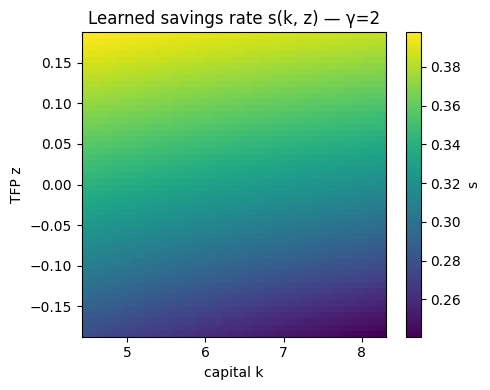

In [3]:
def state_grid(net, n=50):
    """Grid over ±2σ of the ergodic support around the network's SS."""
    k_ss = float(net.ss_state[0])
    z_ss = float(net.ss_state[1])
    sigma_z = 0.04
    rho = 0.9
    z_std = sigma_z / np.sqrt(1.0 - rho**2)
    ks = np.linspace(0.7 * k_ss, 1.3 * k_ss, n)
    zs = np.linspace(z_ss - 2 * z_std, z_ss + 2 * z_std, n)
    K, Z = np.meshgrid(ks, zs)
    states = jnp.stack([K.ravel(), Z.ravel()], axis=-1)
    return states, K, Z


states, K, Z = state_grid(net)
policy = np.asarray(net(states)).reshape(K.shape)

fig, ax = plt.subplots(figsize=(5, 4))
pcm = ax.pcolormesh(K, Z, policy, shading="auto", cmap="viridis")
ax.set_xlabel("capital k")
ax.set_ylabel("TFP z")
ax.set_title("Learned savings rate s(k, z) — γ=2")
fig.colorbar(pcm, ax=ax, label="s")
fig.tight_layout()
fig.savefig(f"{FIGDIR}/ch0_policy_gamma2.png", dpi=150)
plt.show()

## Chapter 1 — Output decomposition

The first mech-interp move on any model is the same: try to write the
output as a sum of separately-interpretable components. `LinearPlusMLP`
gives us this for free.

```
policy(s) = π_BK(s) + δ_θ(s)   (linear-link case; clipping aside)
              ↑          ↑
        perturbation   the only thing
        theory's       the neural net adds
        prediction
```

Macro people: π_BK is what you'd get from a Blanchard-Kahn solver. δ_θ
is the network's nonlinear correction.

ML people: this is a residual network with a hand-derived skip
connection.

Closes numerically on grid: True


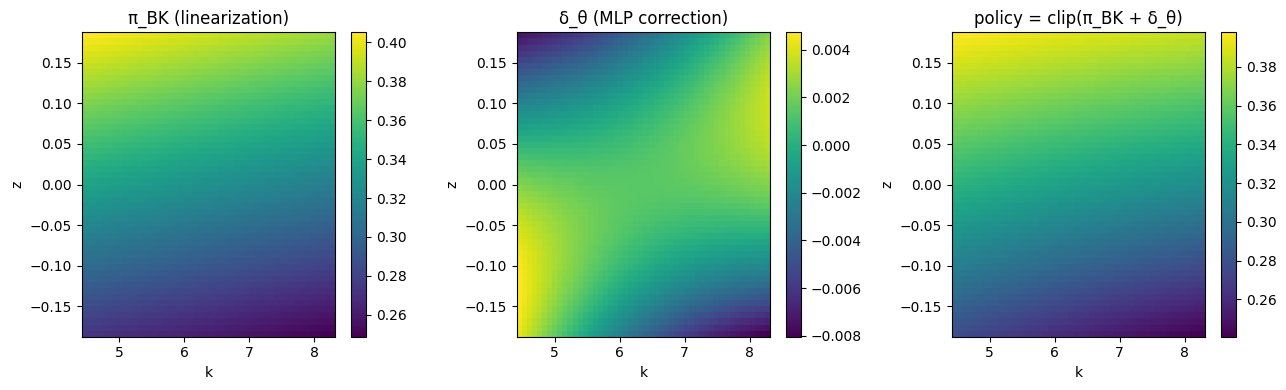

|π_BK|_max = 0.4052
|δ_θ|_max  = 0.0080
ratio δ/π  = 1.982%


In [4]:
bd = branch_decompose(net, states)
print(f"Closes numerically on grid: {bool(bd['closes_numerically'])}")

bk = np.asarray(bd["bk"]).reshape(K.shape)
mlp_delta = np.asarray(bd["mlp_delta"]).reshape(K.shape)
combined = np.asarray(bd["policy"]).reshape(K.shape)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, arr, title in zip(
    axes,
    (bk, mlp_delta, combined),
    ("π_BK (linearization)", "δ_θ (MLP correction)", "policy = clip(π_BK + δ_θ)"),
):
    pcm = ax.pcolormesh(K, Z, arr, shading="auto", cmap="viridis")
    ax.set_xlabel("k")
    ax.set_ylabel("z")
    ax.set_title(title)
    fig.colorbar(pcm, ax=ax)
fig.tight_layout()
fig.savefig(f"{FIGDIR}/ch1_decomposition_gamma2.png", dpi=150)
plt.show()

print(f"|π_BK|_max = {np.abs(bk).max():.4f}")
print(f"|δ_θ|_max  = {np.abs(mlp_delta).max():.4f}")
print(f"ratio δ/π  = {np.abs(mlp_delta).max() / np.abs(bk).max():.3%}")

Two things to notice:

- `closes_numerically` is true — `π_BK + δ_θ` reconstructs the policy
  exactly on the grid. No clipping fires inside the ergodic support.
- The MLP correction is a small fraction of the BK baseline in
  magnitude, but its spatial pattern is *structured*. The next chapter
  opens that pattern up.

## Chapter 2 — Per-neuron contributions

The MLP correction is computed by a small network — at this size,
`(16, 16)` hidden units. Not every neuron does the same amount of work.
The simplest interp move is to ask, for each neuron in the last hidden
layer, how much it actually contributes to the output.

Per-neuron contribution to the network's output is
`W_last[j, i] · h_last[i]` — the weight times the post-activation.
Summed across `i`, this plus the last-layer bias reconstructs the
pre-bounds MLP output.

Three archetypes appear in any small MLP:
- **dead** — near-zero activation everywhere.
- **generic** — smooth, roughly-linear-in-state; carries a low-order trend.
- **selective** — strong only in part of state space; the interesting
  case for interp.

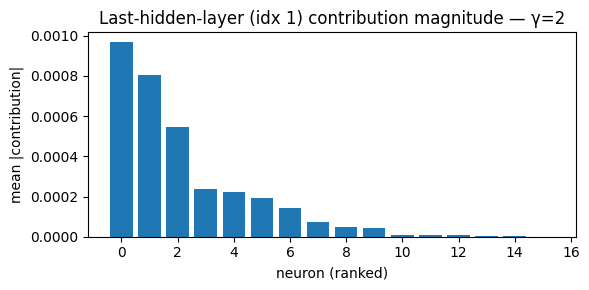

ranked neuron indices (descending): [1, 9, 12, 5, 11, 3, 0, 6, 15, 8, 2, 7, 13, 14, 4, 10]


In [5]:
contribs = neuron_contributions(net.mlp, states)
last_layer_idx = max(contribs.keys())  # 1 if hidden=(16,16), 0 if (16,)
contrib_last = np.asarray(contribs[last_layer_idx])  # [batch, H, 1]
mean_abs = np.abs(contrib_last[..., 0]).mean(axis=0)
order = np.argsort(-mean_abs)

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(len(mean_abs)), mean_abs[order])
ax.set_xlabel("neuron (ranked)")
ax.set_ylabel("mean |contribution|")
ax.set_title(
    f"Last-hidden-layer (idx {last_layer_idx}) contribution magnitude — γ=2"
)
fig.tight_layout()
fig.savefig(f"{FIGDIR}/ch2_contribution_bar_gamma2.png", dpi=150)
plt.show()
print("ranked neuron indices (descending):", order.tolist())

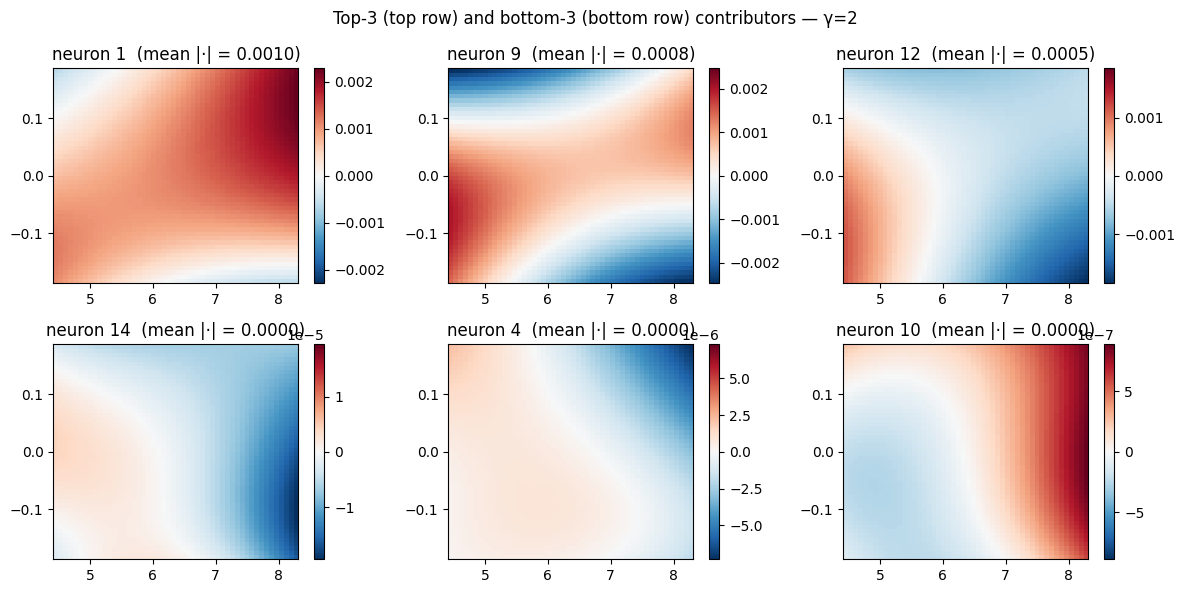

In [6]:
H_last = contrib_last.shape[1]
picks = list(order[:3]) + list(order[-3:])
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, i in zip(axes.flat, picks):
    grid = contrib_last[:, i, 0].reshape(K.shape)
    vmax = max(np.abs(grid).max(), 1e-12)
    pcm = ax.pcolormesh(
        K, Z, grid, shading="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax
    )
    ax.set_title(f"neuron {i}  (mean |·| = {mean_abs[i]:.4f})")
    fig.colorbar(pcm, ax=ax)
fig.suptitle("Top-3 (top row) and bottom-3 (bottom row) contributors — γ=2")
fig.tight_layout()
fig.savefig(f"{FIGDIR}/ch2_contribution_heatmaps_gamma2.png", dpi=150)
plt.show()

**Sanity check:** for any neuron `i` in the last hidden layer,
summing its contribution across all neurons + the last-layer bias gives
back the network's pre-bias MLP output:

In [7]:
acts = forward_with_activations(net.mlp, states)
summed = contrib_last.sum(axis=1)  # [batch, 1]
bias = np.asarray(net.mlp.layers[-1].bias)
out = np.asarray(acts["out"])
print(f"max |summed + bias - out| = {np.abs(summed + bias - out).max():.2e}")
assert np.allclose(summed + bias[None, :], out, atol=1e-5)

max |summed + bias - out| = 9.31e-10


If the bar chart shows most contribution concentrated in a few
neurons and the rest near zero, the network learned a sparse solution
and the analysis ahead has a clear target. If the bar is uniform, the
network spread the work — more honest probes will be needed.